# EO-LINCS project: Cube generation for Scientific Case Study (SCS) 4 

## EO enhanced benchmarking of GCB DGVMs

**Objective**: SCS4 aims to deepen the understanding of the processes that drive the European land carbon sink, with a focus on productivity, turnover, and the impacts of disturbances and land management. Leveraging new EO data and the International Land Model Benchmarking (ILAMB) system, it will assess Dynamic Global Vegetation Models (DGVMs) that contribute to the Global Carbon Budget (GCB) reports. The project will result in an enhanced ILAMB tool, offering insights into carbon dynamics and DGVM performance, and providing a roadmap for future model improvements.

**Outcomes**: An enhanced ILAMB evaluation tool with a focus on internal carbon dynamics and temporal 
change able to provide novel insights into DGVM capabilities to simulate the European land carbon sink and 
identify its main drivers. The spatiotemporal analysis will enable us to produce a roadmap for model 
improvements, in particular regarding forest management

**Requried datasets**:
* [ESA-CCI Biomass](https://climate.esa.int/en/projects/biomass/)
* [Changes in Global Terrestrial Live Biomass over the 21st Century](https://zenodo.org/records/4161694)

-------------------------------------------------------------

#### The following notebook shows how the users can load data from various sources defined in `scs4_config.yml` using the `MultiSourceDataStore` tool.

#### **What You Can Do with This Notebook** 
- Load datasets from various sources as defined in the `scs4_config.yml`
- View the progress of each data request to the `MultiSourceDataStore`
- Quickly preview the datasets by plotting them.

#### **Requirements**  
Before proceeding, ensure you have the necessary dependencies installed:
- install `xcube-multistore` by executing: `conda install --channel conda-forge xcube-multistore`

Once you have it installed, you are ready to proceed.

This Multistore mainly works with a file called `scs4_config.yml` which is at the same file level as this notebook.
To understand what goes into the schema, you can read more [here](https://xcube-dev.github.io/xcube-multistore/).

-------------------------------------------------------

Let's import the `MultiSourceDataStore`

In [1]:
from xcube_multistore import MultiSourceDataStore

You can find out how to fill out the config file by also using this super helpful function `get_config_schema()`. Run it and try expand the fields to learn more about the possible properties that the configuration file accepts along with the [Configuration Guide](https://xcube-dev.github.io/xcube-multistore/config/).

In [2]:
MultiSourceDataStore.get_config_schema()

To set up the config file, please refer to the notebook [setup_config.ipynb](../setup_config.ipynb) or the [Configuration Guide](https://xcube-dev.github.io/xcube-multistore/config/) in the documentation.

Now, we can initialize the `MultiSourceDataStore` by passing the path to the `scs4_config.yml` which currently is on the same level as this notebook.

>**NOTE**: In the `scs4_config.yml` we are also using the `custom_processing` feature of this tool that allows us to run a function for processing each dataset separately. In this example, we have defined a module called `modify_dataset` that does some custom processing which takes a `xarray.Dataset` argument as input and returns a new `xarray.Dataset` object. To read more about this `custom_processing` function, you can see more [here](https://xcube-dev.github.io/xcube-multistore/config/#custom_processing).

In [3]:
msds = MultiSourceDataStore("scs4_config.yml")

And we can display the overview of the configuration file for each dataset.

In [4]:
msds.display_config()

User-defined ID,Data Store ID,Data Store Params,Data ID,Open Data Params,Grid-Mapping,Format
biomass_xu,zenodo,root: 4161694,test10a_cd_ab_pred_corr_2000_2019_v2.tif,band_as_variable: False,"bbox: [-180, -90, 180, 90]; spatial_res: 0.1; crs: EPSG:4326; tile_size: [1800, 1800]",netcdf
esa_cci_biomass,cciodp,-,esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.MERGED.5-0.10000m,-,"bbox: [-180, -90, 180, 90]; spatial_res: 0.1; crs: EPSG:4326; tile_size: [1800, 1800]",netcdf


We can display the selected bounding box as shown in the following cell.

In [5]:
msds.display_geolocations()

We can now generate the datacubes:

In [6]:
msds.generate()

Dataset identifier,Status,Message,Exception
biomass_xu,COMPLETED,Dataset 'biomass_xu' finished: 0:01:08,-
esa_cci_biomass,COMPLETED,Dataset 'esa_cci_biomass' finished: 0:01:10,-


We can now open the data using the xcube datastore framework API as usual. Note that the multi-source data store requires a data store called `storage`, which is configured in our `scs4_config.yml` under the `data_stores` section.

In [7]:
ds = msds.stores.storage.open_data("biomass_xu.nc", chunks="auto")
ds

<xarray.Dataset> Size: 518MB
Dimensions:         (time: 20, lat: 1800, lon: 3600)
Coordinates:
  * time            (time) datetime64[ns] 160B 2000-01-01 ... 2019-01-01
  * lat             (lat) float64 14kB 89.95 89.85 89.75 ... -89.85 -89.95
  * lon             (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9
    spatial_ref     int64 8B ...
Data variables:
    carbon_density  (time, lat, lon) float32 518MB dask.array<chunksize=(12, 1181, 2365), meta=np.ndarray>

We can now select a variable for one timestep and plot it for a quick preview of the data

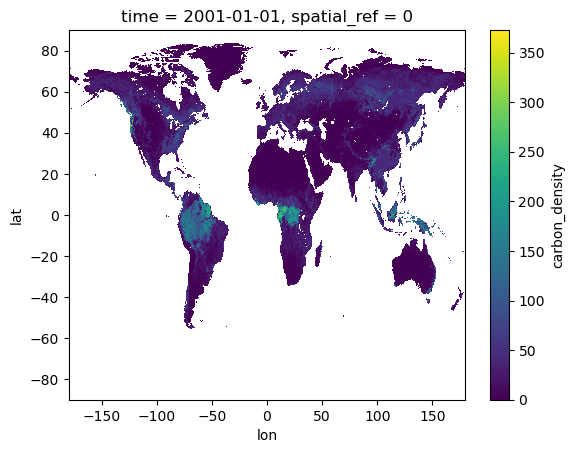

In [8]:
ds.carbon_density.isel(time=1).plot()

In [9]:
ds = msds.stores.storage.open_data("esa_cci_biomass.nc", chunks="auto")
ds

<xarray.Dataset> Size: 415MB
Dimensions:      (time: 8, lat: 1800, lon: 3600)
Coordinates:
  * time         (time) datetime64[ns] 64B 2010-07-02 2015-07-02 ... 2021-07-02
  * lat          (lat) float64 14kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * lon          (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.7 179.8 179.9
    spatial_ref  int64 8B ...
Data variables:
    agb          (time, lat, lon) float32 207MB dask.array<chunksize=(6, 1671, 3344), meta=np.ndarray>
    agb_sd       (time, lat, lon) float32 207MB dask.array<chunksize=(6, 1671, 3344), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    title:                   esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-plat...
    date_created:            2026-02-11T10:34:10.439330
    processing_level:        L4
    time_coverage_start:     2010-01-01T00:00:00
    time_coverage_end:       2021-12-31T00:00:00
    time_coverage_duration:  P4382DT0H0M0S
    history:                 [{'program': 'xcube_cci.chunkstore.CciChunkStore...

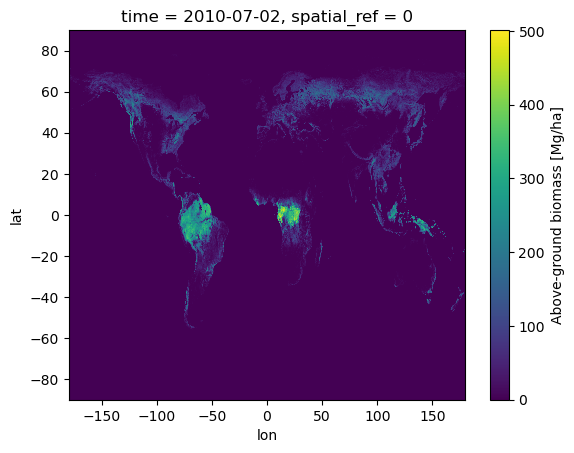

In [10]:
ds.agb.isel(time=0).plot()

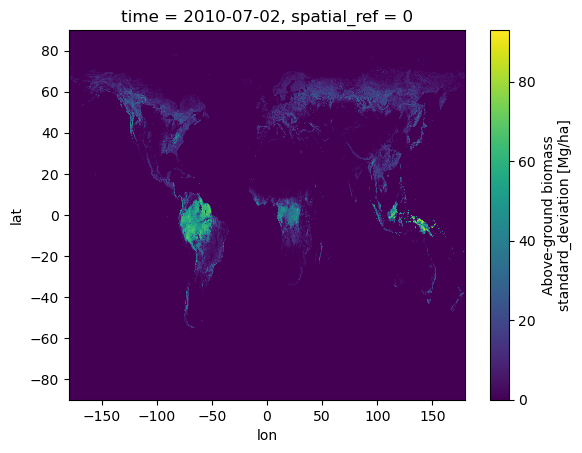

In [11]:
ds.agb_sd.isel(time=0).plot()